# **LOSS-WEIGHTED TRAINING WARNING**

**THIS NOTEBOOK USES CLASSIFICATION RESULTS TRAINED WITH CLASS-WEIGHTED LOSS INSTEAD OF WEIGHTED WINDOW SAMPLING. ITS MODEL COMPARISONS SHOULD NOT BE INTERPRETED AS RESULTS FROM THE CORRECTED SAMPLING PROCEDURE.**


# Native presynaptic skeleton comparison

Compare Mean, Pointwise-MLP, and GT on native, local-center skeleton windows. Each section runs from the coarsest scale (b32) to the densest available scale. Results for a scale appear when its files are available.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "results" / "presynaptic").is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from analysis.presynaptic.new_skeletons_native.skeleton_comparison_native import (
    RESULT_ROOT, MIXED_RESULT_ROOT, load_summaries, load_training_curves,
    plot_confusions, plot_metric_comparison, plot_training_curves,
)
RESULT_ROOT

PosixPath('/home/jcbliao/rotation/segclr/gnn_classifier/results/presynaptic/new_skeletons_native/local_center')

## Training progress

,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_pyramidal,window_precision_thalamocortical,cell_precision_putative_cge,cell_precision_putative_parvalbumin,cell_precision_putative_somatostatin,cell_precision_pyramidal,cell_precision_thalamocortical,scale,run,model
270,29,0.304253,0.797435,0.737671,0.719298,0.705188,0.927602,0.777637,0.910362,0.819427,...,0.837778,0.605342,0.640000,0.971429,1.000000,0.940379,1.0,32,gnn_lcpn_scratch_mean_resnet4x128_n9_fold0,Mean
300,29,0.305664,0.797511,0.741247,0.723597,0.707354,0.927602,0.777637,0.905950,0.817827,...,0.840531,0.621610,0.615385,0.971429,1.000000,0.942935,1.0,32,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
240,29,0.311292,0.800509,0.749218,0.723194,0.709348,0.929864,0.778212,0.911695,0.820930,...,0.854969,0.591704,0.615385,1.000000,1.000000,0.943089,1.0,32,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n9_fold0,GT
101,29,0.290867,0.748574,0.696206,0.721982,0.673492,0.920814,0.749046,0.898712,0.790946,...,0.787152,0.697362,0.555556,1.000000,1.000000,0.938005,1.0,16,gnn_lcpn_scratch_mean_resnet4x128_n17_fold0,Mean
131,29,0.292911,0.734205,0.689005,0.722107,0.665126,0.920814,0.749392,0.901887,0.792791,...,0.775881,0.720088,0.571429,1.000000,1.000000,0.938005,1.0,16,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
71,29,0.290747,0.744899,0.707179,0.730642,0.676311,0.929864,0.770653,0.908332,0.802085,...,0.800227,0.702153,0.588235,1.000000,1.000000,0.953425,1.0,16,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_fold0,GT
450,29,0.294975,0.803518,0.739430,0.734986,0.718673,0.936652,0.809785,0.943758,0.857971,...,0.834066,0.686348,0.809524,0.971429,1.000000,0.937838,1.0,8,gnn_lcpn_scratch_mean_resnet4x128_n33_fold0,Mean
480,29,0.296575,0.796963,0.741465,0.743149,0.717191,0.932127,0.789758,0.921334,0.831386,...,0.843488,0.714037,0.692308,0.971429,1.000000,0.942935,1.0,8,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
420,29,0.296689,0.776812,0.724801,0.749957,0.701458,0.932127,0.784488,0.903645,0.812407,...,0.856481,0.757611,0.588235,0.971429,1.000000,0.958564,1.0,8,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n33_fold0,GT
360,29,0.291616,0.798934,0.717359,0.745765,0.715256,0.929864,0.783482,0.941156,0.836579,...,0.814598,0.773057,0.777778,1.000000,1.000000,0.928000,1.0,4,gnn_lcpn_scratch_mean_resnet4x128_n65_fold0,Mean


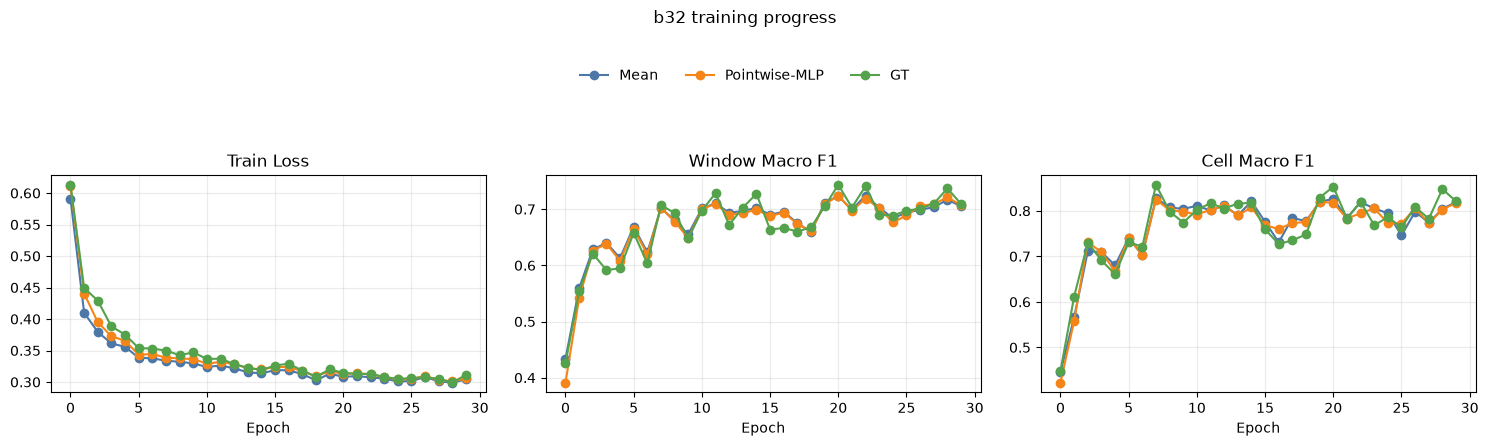

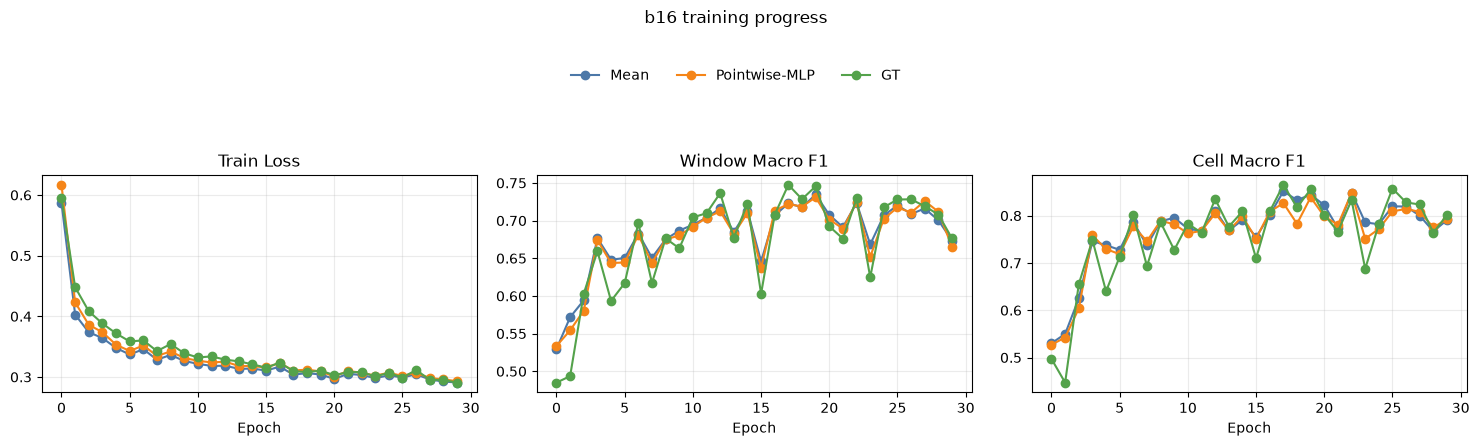

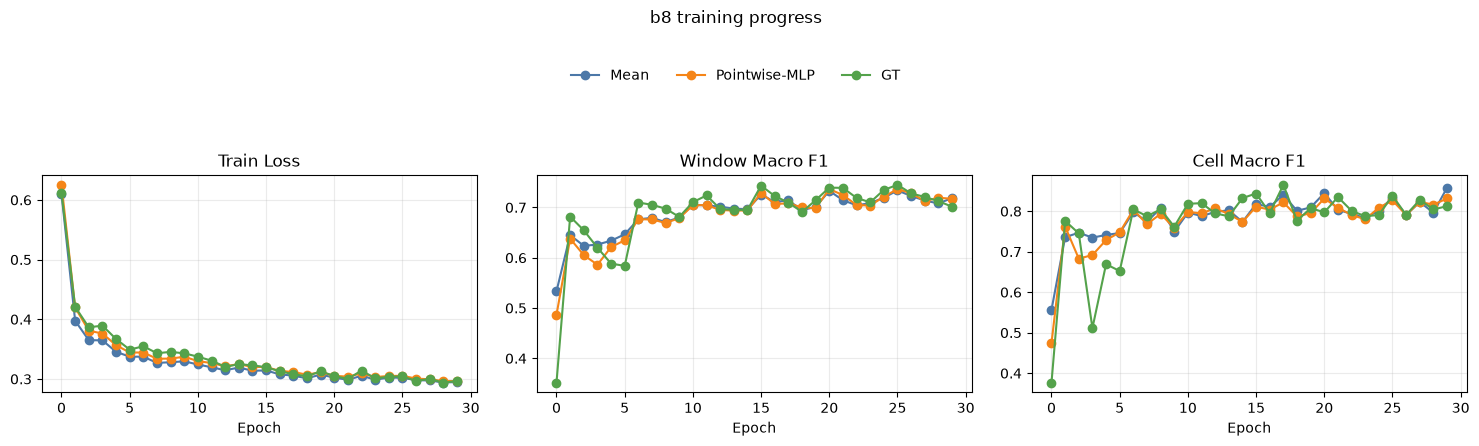

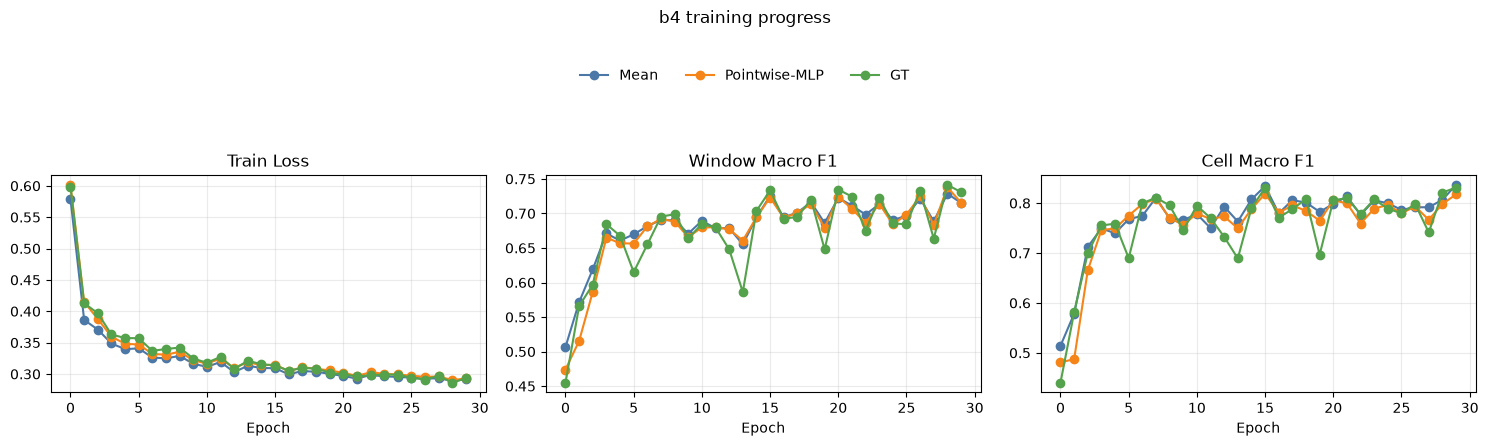

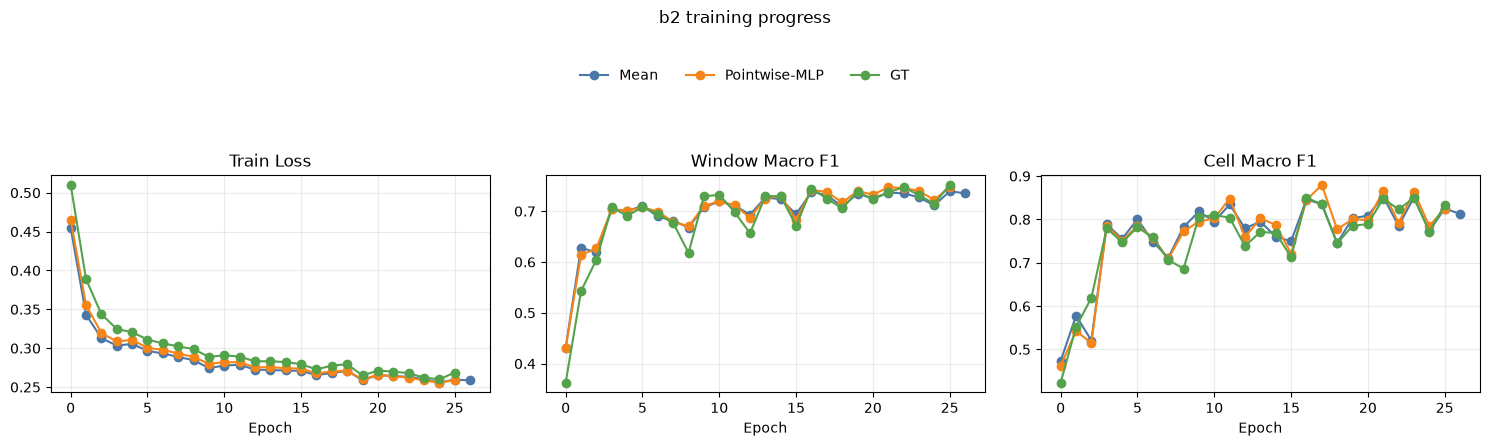

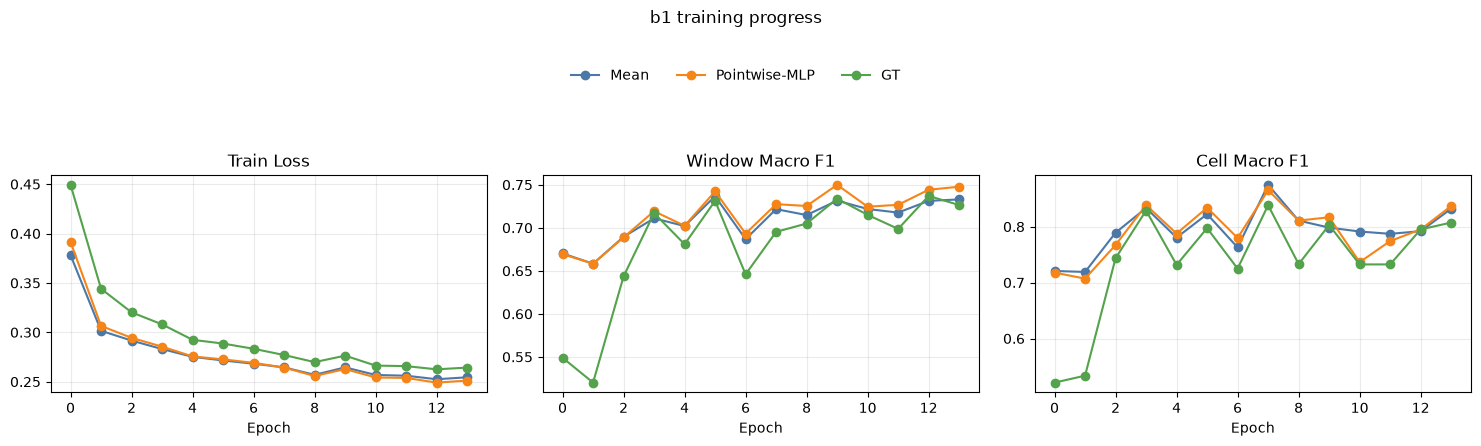

In [2]:
curves = load_training_curves()
if curves.empty:
    print("No completed epochs yet.")
else:
    display(curves.groupby(["scale", "model", "run"], observed=True).tail(1)
            .sort_values(["scale", "model"], ascending=[False, True]))
    for fig in plot_training_curves(curves):
        display(fig)
        plt.close(fig)

## Mixed-cell training progress

The separate b32 run mixes windows from several cells per optimizer batch while retaining the same windows and number of batches per epoch.

,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_pyramidal,window_precision_thalamocortical,cell_precision_putative_cge,cell_precision_putative_parvalbumin,cell_precision_putative_somatostatin,cell_precision_pyramidal,cell_precision_thalamocortical,scale,run,model
59,29,0.251589,0.825771,0.754948,0.704374,0.713828,0.929864,0.813115,0.921152,0.845390,...,0.851383,0.492978,0.857143,0.918919,0.894737,0.934959,1.0,32,gnn_lcpn_scratch_mean_resnet4x128_n9_mixed16_f...,Mean
89,29,0.248421,0.835227,0.767336,0.719770,0.730922,0.932127,0.819176,0.904808,0.846428,...,0.861271,0.542334,0.812500,0.918919,0.850000,0.942623,1.0,32,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,Pointwise-MLP
29,29,0.260535,0.830859,0.755065,0.704366,0.714699,0.925339,0.801210,0.878552,0.827591,...,0.858232,0.497518,0.722222,0.894737,0.833333,0.942466,1.0,32,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n9_mixed...,GT


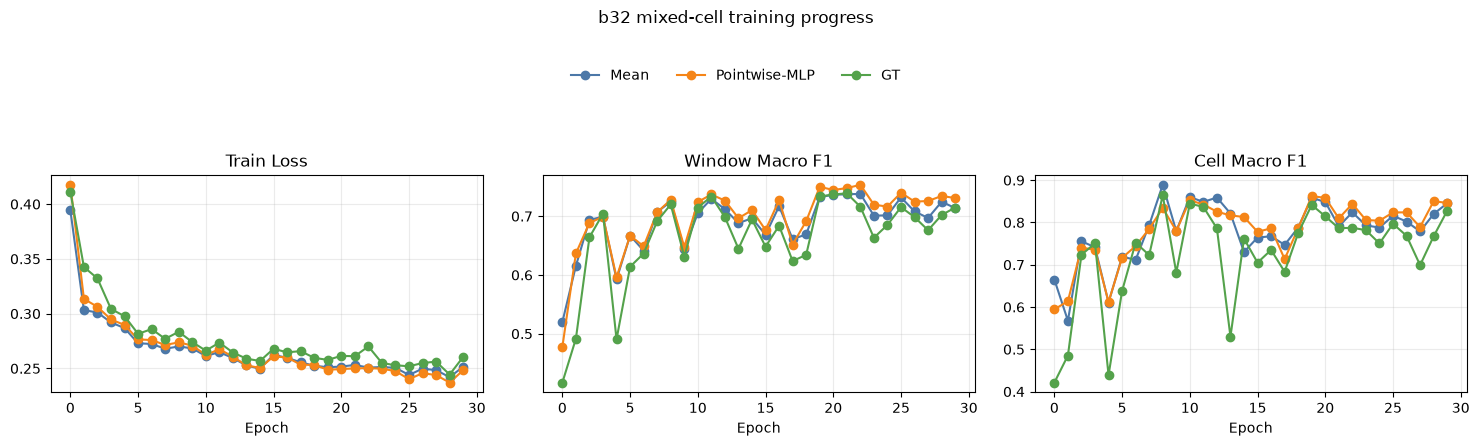

In [3]:
mixed_curves = load_training_curves(MIXED_RESULT_ROOT)
if mixed_curves.empty:
    print("Mixed-cell training has not produced epoch metrics yet.")
else:
    display(mixed_curves.groupby(["scale", "model", "run"], observed=True).tail(1)
            .sort_values(["scale", "model"], ascending=[False, True]))
    for fig in plot_training_curves(mixed_curves, experiment="mixed-cell"):
        display(fig)
        plt.close(fig)

## Final metrics

,scale,model,run,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1
0,32,Mean,gnn_lcpn_scratch_mean_resnet4x128_n9_fold0,0.813482,0.726715,0.741914,0.724322,0.925339,0.771361,0.916535,0.819096
1,32,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,0.811663,0.715034,0.751948,0.724117,0.925339,0.771361,0.907029,0.817321
2,32,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n9_fold0,0.827502,0.731777,0.767436,0.743330,0.936652,0.812204,0.927879,0.852924
3,16,Mean,gnn_lcpn_scratch_mean_resnet4x128_n17_fold0,0.816928,0.730728,0.758969,0.734665,0.934389,0.798238,0.923315,0.844452
4,16,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,0.813014,0.728645,0.758335,0.731041,0.932127,0.789543,0.929105,0.838885
5,16,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n17_fold0,0.834736,0.738406,0.765145,0.747499,0.941176,0.829595,0.945251,0.865248
6,8,Mean,gnn_lcpn_scratch_mean_resnet4x128_n33_fold0,0.824746,0.737428,0.740446,0.733809,0.929864,0.788752,0.921096,0.833489
7,8,Pointwise-MLP,gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_...,0.832568,0.738208,0.742111,0.736524,0.929864,0.796657,0.935600,0.831493
8,8,GT,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n33_fold0,0.830956,0.753606,0.746772,0.744977,0.932127,0.800083,0.924247,0.838200
9,4,Mean,gnn_lcpn_scratch_mean_resnet4x128_n65_fold0,0.830597,0.717818,0.753965,0.728666,0.920814,0.764510,0.918641,0.806582


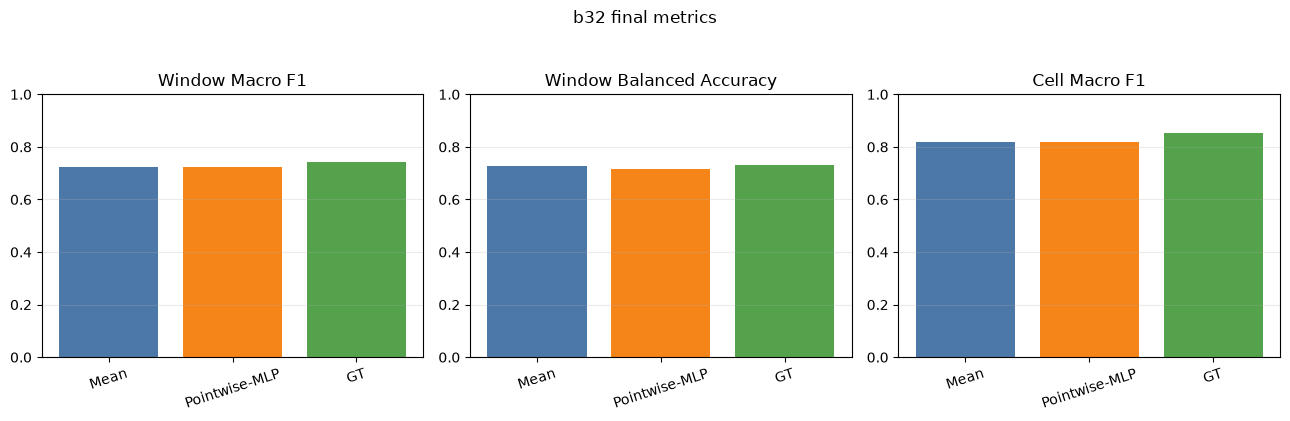

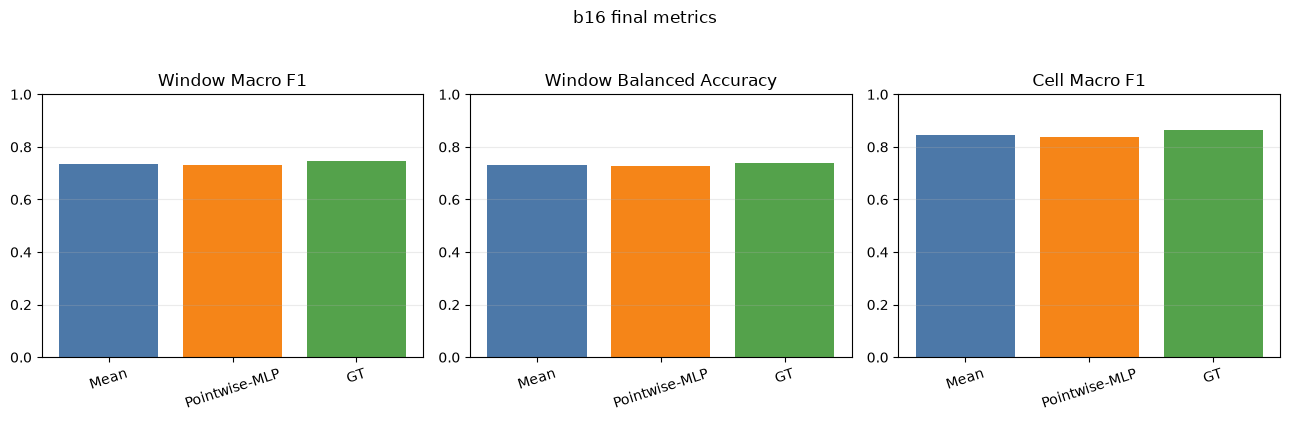

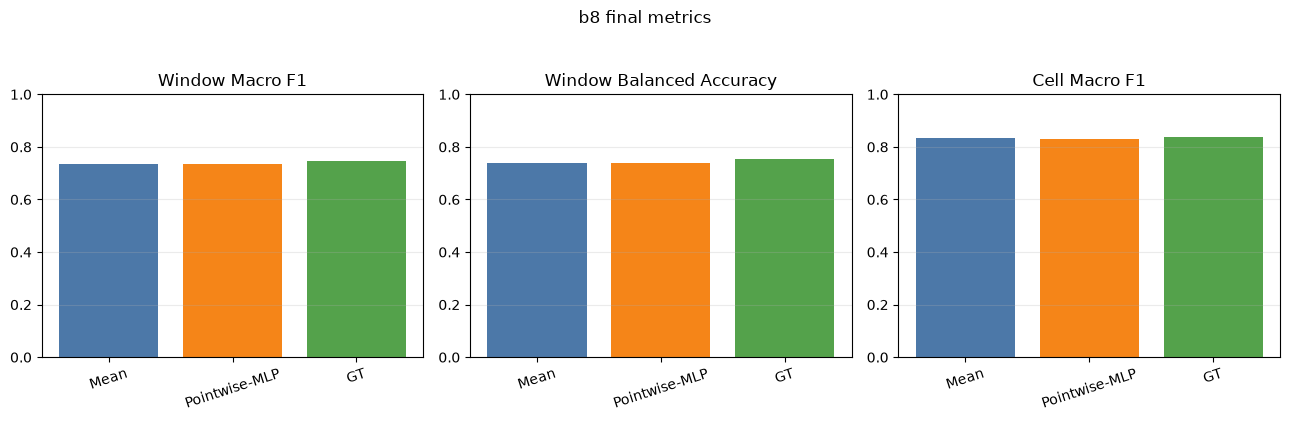

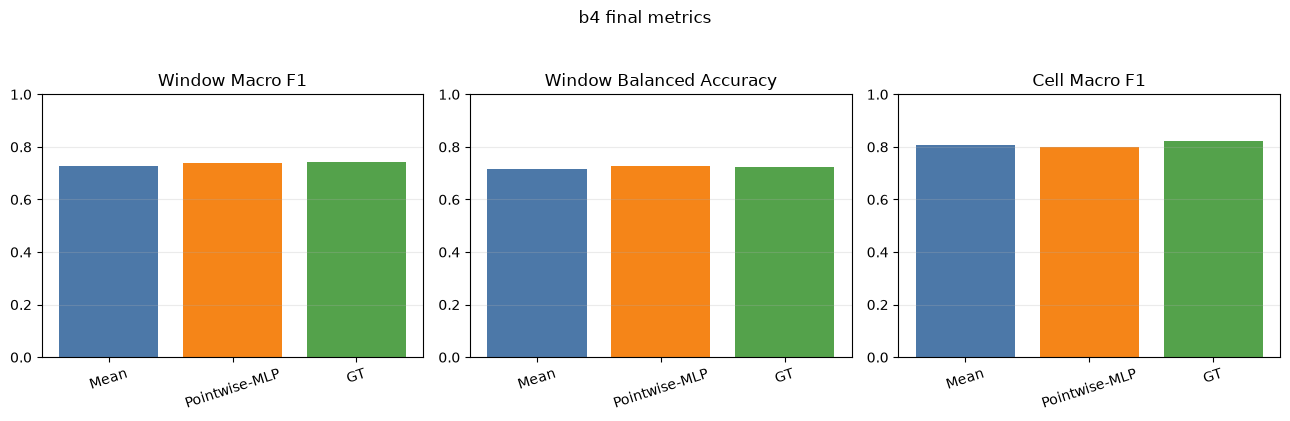

In [4]:
summary, payloads = load_summaries()
if summary.empty:
    print("Final summaries appear after training finishes.")
else:
    display(summary)
    for fig in plot_metric_comparison(summary):
        display(fig)
        plt.close(fig)

## Confusion matrices

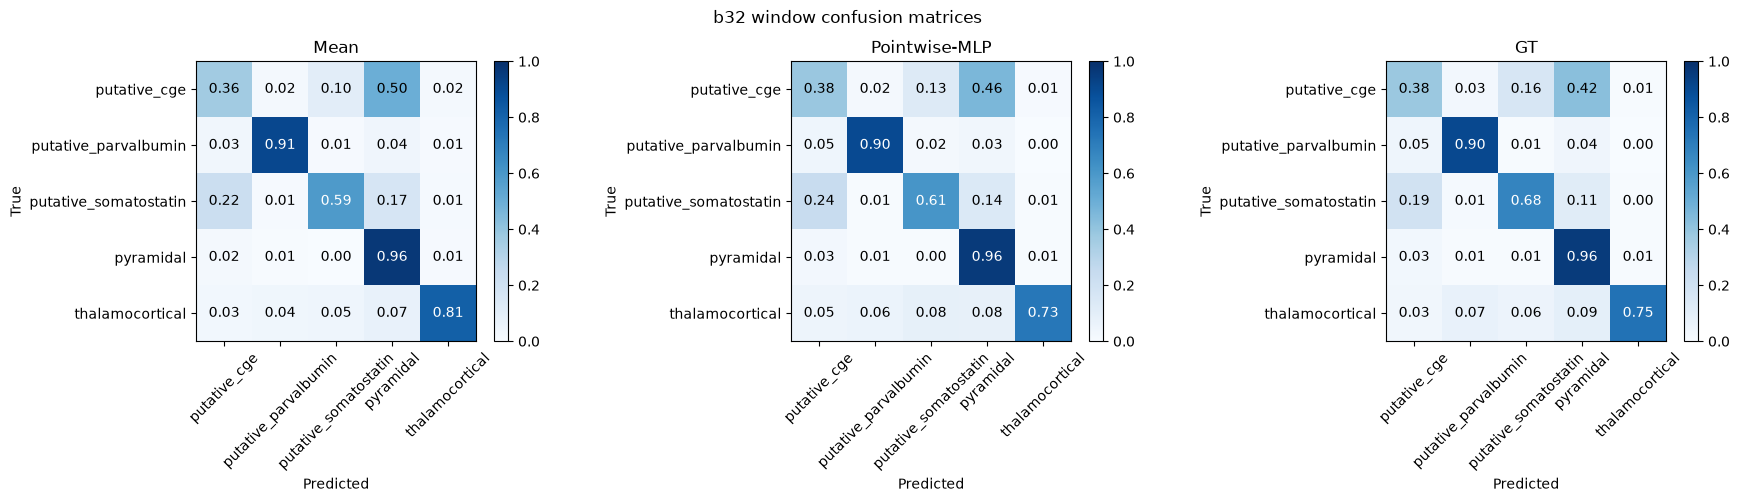

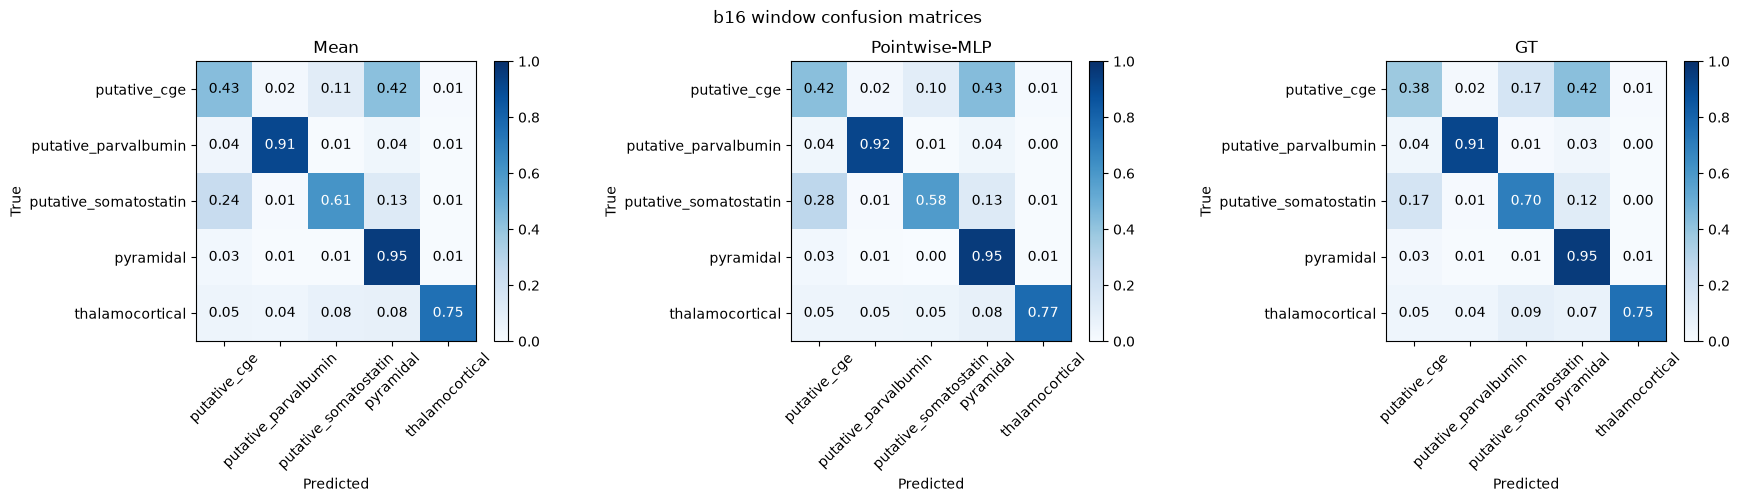

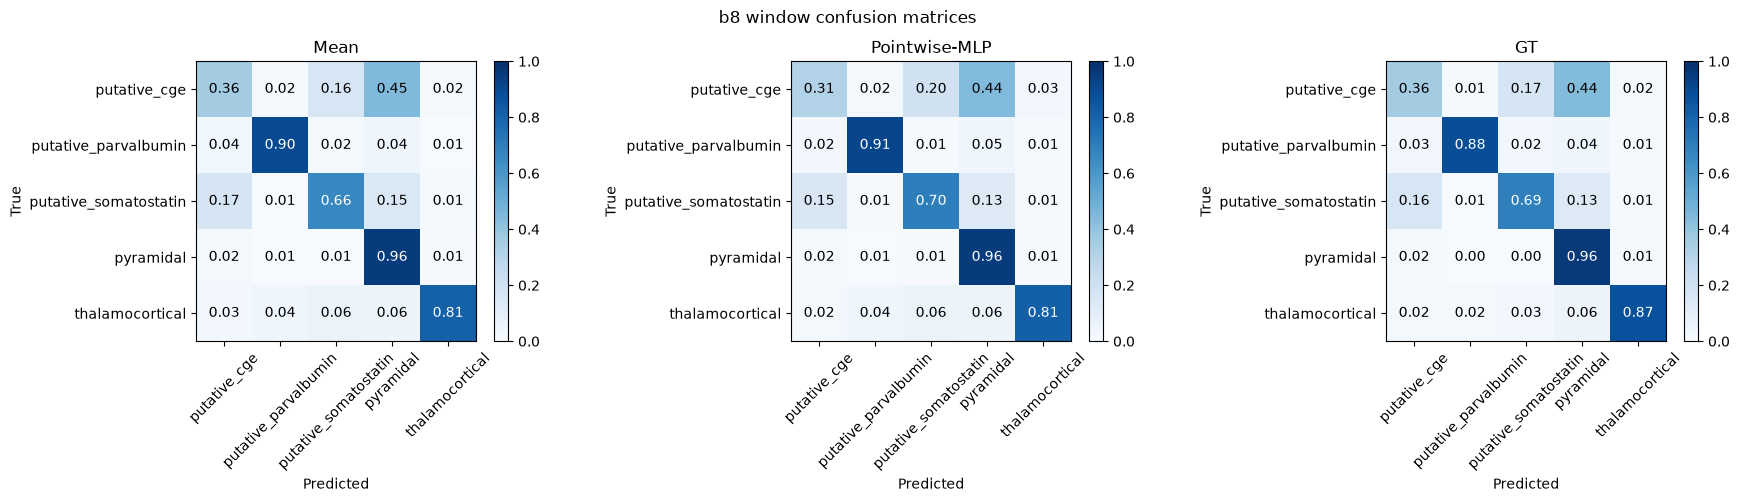

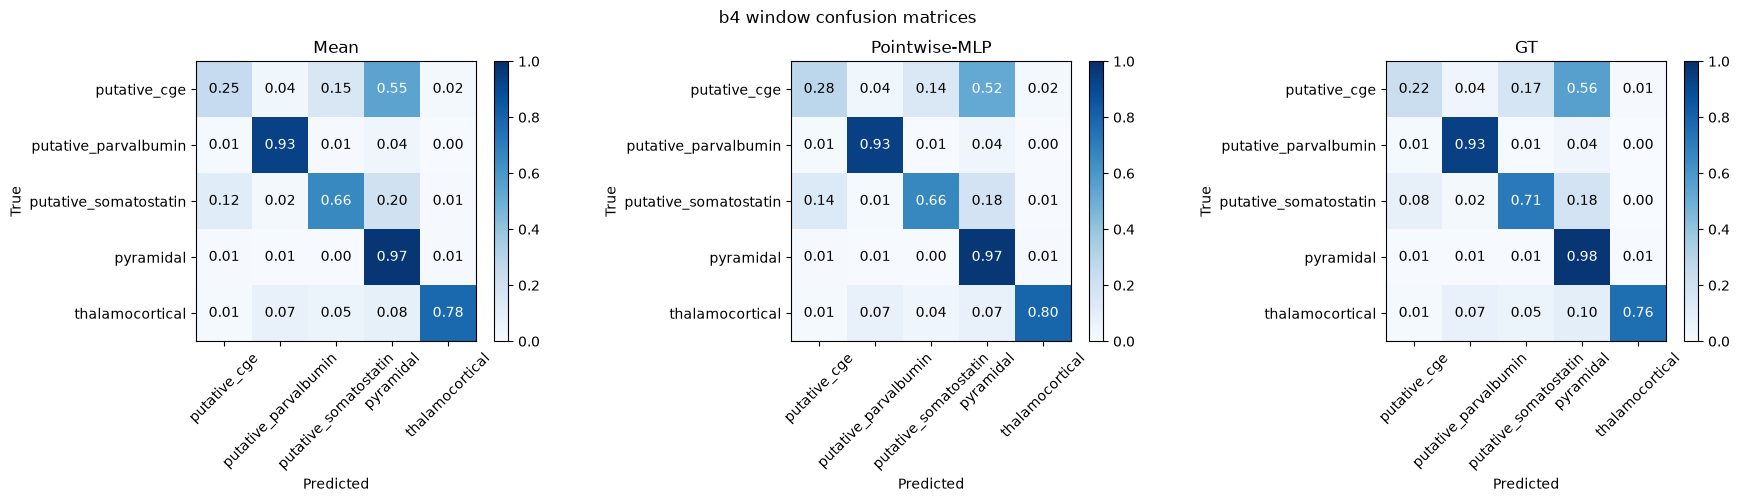

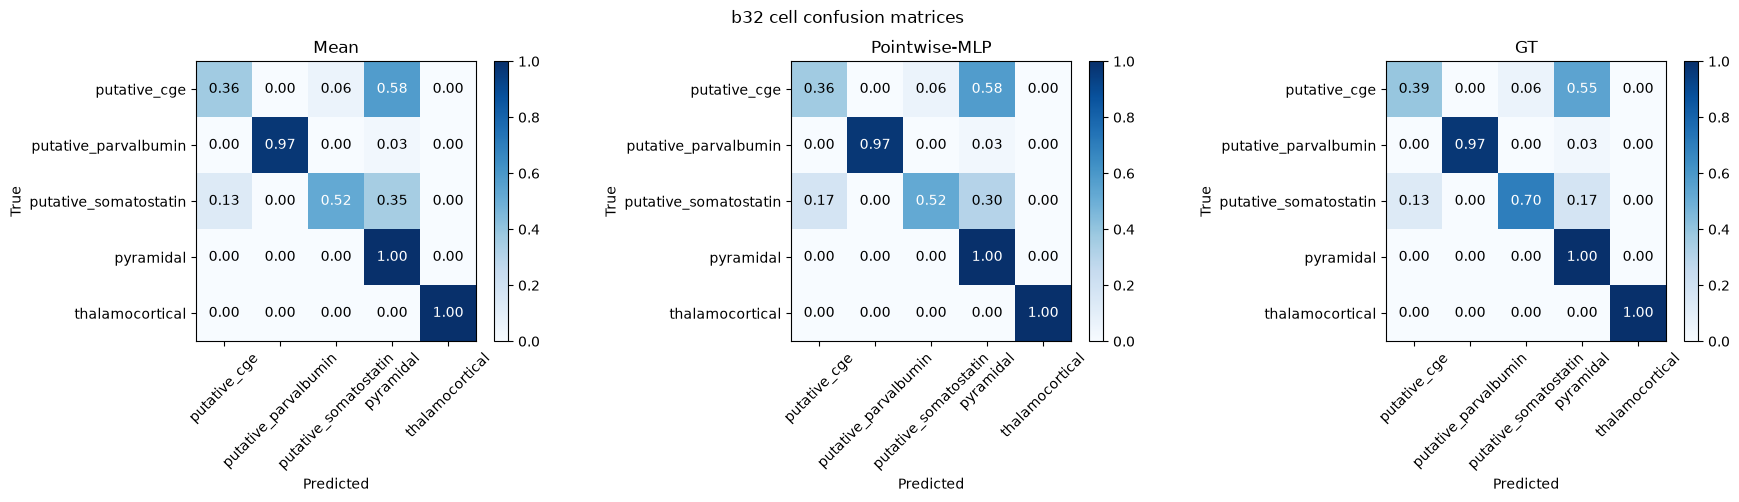

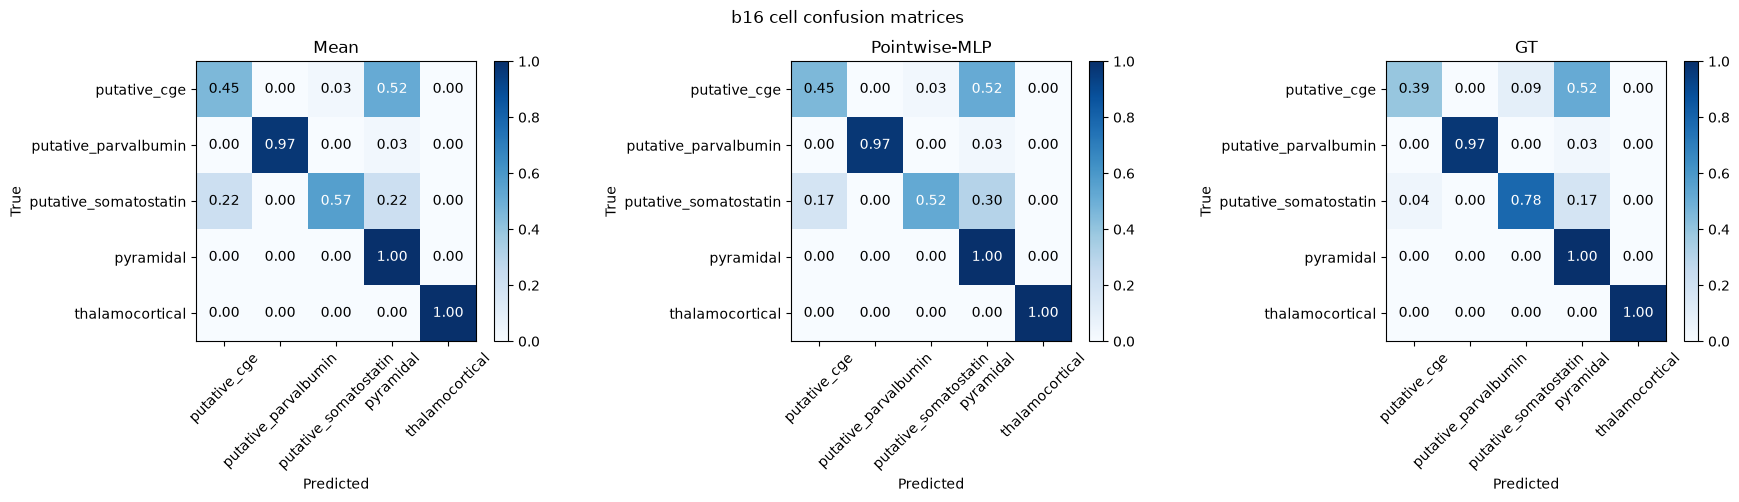

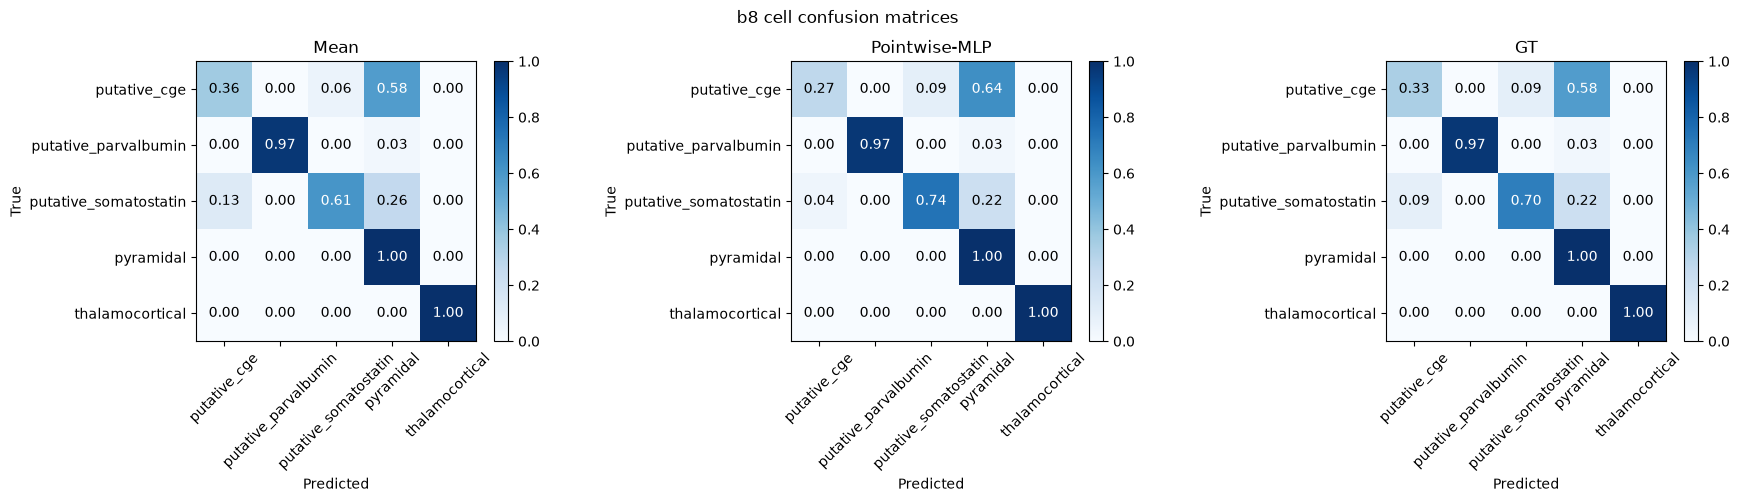

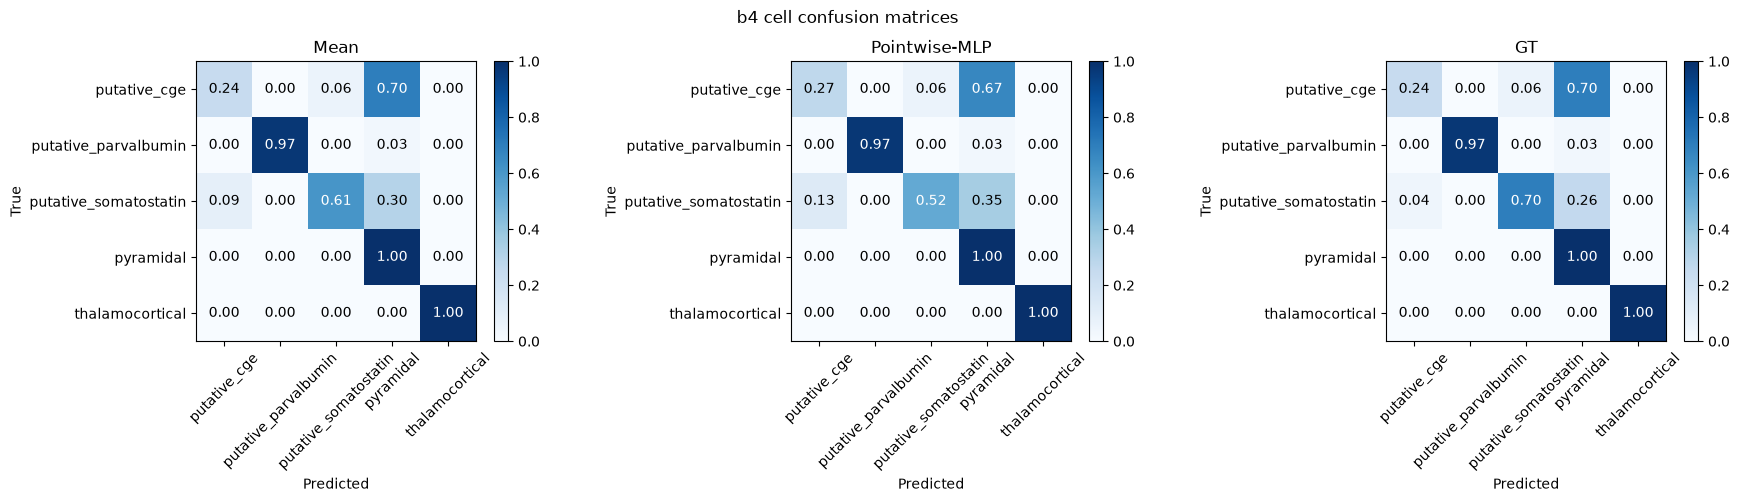

In [5]:
for scope in ("window", "cell"):
    for fig in plot_confusions(payloads, scope=scope, normalize=True):
        display(fig)
        plt.close(fig)